In [14]:
import os

NIH_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
CSV_PATH = f'{NIH_DIR}/Data_Entry_2017.csv'

print(f'CSV existe : {os.path.exists(CSV_PATH)}')
print(f'Images 001 : {os.path.exists(f"{NIH_DIR}/images_001")}')

CSV existe : True
Images 001 : True


In [15]:
!pip install mlflow -q
print('✅ OK')

✅ OK


In [28]:
import os

print('Contenu de /kaggle/working :')
for f in os.listdir('/kaggle/working'):
    print(f'  {f}')

print('\nModèles sauvegardés :')
models_dir = '/kaggle/working/models'
if os.path.exists(models_dir):
    for f in os.listdir(models_dir):
        size = os.path.getsize(f'{models_dir}/{f}') / 1e6
        print(f'  {f} ({size:.1f} Mo)')
else:
    print('  ❌ Dossier models introuvable !')

Contenu de /kaggle/working :
  images_resized
  mlruns
  .virtual_documents
  figures
  models

Modèles sauvegardés :
  MM_ImageOnly_best.pth (0.5 Mo)
  MM_TextOnly_best.pth (0.9 Mo)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, random
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
from sklearn.model_selection import train_test_split
import mlflow

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
IMG_SIZE   = 64
NIH_DIR    = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
WORK_DIR   = '/kaggle/working'
os.makedirs(f'{WORK_DIR}/models',  exist_ok=True)
os.makedirs(f'{WORK_DIR}/figures', exist_ok=True)

mlflow.set_tracking_uri(f'file://{WORK_DIR}/mlruns')
mlflow.set_experiment('chest_radiologie_multimodal')

print(f'✅ Config OK | Device : {DEVICE}')

✅ Config OK | Device : cuda


In [18]:
df = pd.read_csv(f'{NIH_DIR}/Data_Entry_2017.csv')
print(f'CSV NIH : {len(df):,} lignes')
print(f'Colonnes : {df.columns.tolist()}')
print(df[['Image Index', 'Finding Labels']].head(5))

PATHOLOGIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]
N_CLASSES = len(PATHOLOGIES)

# Trouver toutes les images disponibles dans tous les dossiers images_XXX
all_images = {}
for folder in sorted(os.listdir(NIH_DIR)):
    folder_path = os.path.join(NIH_DIR, folder)
    if os.path.isdir(folder_path) and folder.startswith('images_'):
        img_subdir = os.path.join(folder_path, 'images')
        if os.path.exists(img_subdir):
            for img in os.listdir(img_subdir):
                all_images[img] = os.path.join(img_subdir, img)

print(f'\nImages disponibles : {len(all_images):,}')

df = df[df['Image Index'].isin(all_images)].reset_index(drop=True)
df['img_path'] = df['Image Index'].map(all_images)
print(f'Images matchées avec CSV : {len(df):,}')

print('\nDistribution des pathologies :')
for p in PATHOLOGIES:
    count = df['Finding Labels'].str.contains(p).sum()
    print(f'  {p:25s} : {count:,}')

CSV NIH : 112,120 lignes
Colonnes : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
        Image Index          Finding Labels
0  00000001_000.png            Cardiomegaly
1  00000001_001.png  Cardiomegaly|Emphysema
2  00000001_002.png   Cardiomegaly|Effusion
3  00000002_000.png              No Finding
4  00000003_000.png                  Hernia

Images disponibles : 112,120
Images matchées avec CSV : 112,120

Distribution des pathologies :
  Atelectasis               : 11,559
  Cardiomegaly              : 2,776
  Effusion                  : 13,317
  Infiltration              : 19,894
  Mass                      : 5,782
  Nodule                    : 6,331
  Pneumonia                 : 1,431
  Pneumothorax              : 5,302
  Consolidation             : 4,667
  Edema                     : 2,303
  Emphysema                 : 2,516
  Fib

In [19]:
def encode_labels(finding_str):
    vec      = np.zeros(N_CLASSES, dtype=np.float32)
    findings = [f.strip() for f in finding_str.split('|')]
    for i, p in enumerate(PATHOLOGIES):
        if p in findings:
            vec[i] = 1.0
    return vec

# Vocabulaire depuis les vrais labels NIH
all_words = set()
for label in df['Finding Labels']:
    for word in label.lower().replace('_', ' ').replace('|', ' ').split():
        all_words.add(word)

VOCAB = {'<pad>': 0, '<unk>': 1}
for w in sorted(all_words):
    VOCAB[w] = len(VOCAB)
VOCAB_SIZE = len(VOCAB)
MAX_LEN    = 20

def tokenize(finding_str):
    words  = finding_str.lower().replace('_', ' ').replace('|', ' ').split()
    tokens = [VOCAB.get(w, 1) for w in words[:MAX_LEN]]
    tokens += [0] * (MAX_LEN - len(tokens))
    return tokens

print(f'✅ Vocabulaire : {VOCAB_SIZE} mots')
print(f'Exemple texte radiologue : "{df["Finding Labels"][0]}"')
print(f'Tokens : {tokenize(df["Finding Labels"][0])}')

✅ Vocabulaire : 19 mots
Exemple texte radiologue : "Cardiomegaly"
Tokens : [3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [20]:
from PIL import Image
import os
from tqdm import tqdm

# Crée un dossier avec les images déjà redimensionnées en 64px
RESIZED_DIR = '/kaggle/working/images_resized'
os.makedirs(RESIZED_DIR, exist_ok=True)

print('⏳ Redimensionnement de toutes les images...')
for img_name, img_path in tqdm(all_images.items()):
    out_path = os.path.join(RESIZED_DIR, img_name)
    if not os.path.exists(out_path):
        img = Image.open(img_path).convert('L')  # Grayscale direct
        img = img.resize((64, 64), Image.LANCZOS)
        img.save(out_path)

print(f'✅ {len(os.listdir(RESIZED_DIR))} images redimensionnées')

# Met à jour le path dans le dataframe
df['img_path'] = df['Image Index'].apply(lambda x: os.path.join(RESIZED_DIR, x))

⏳ Redimensionnement de toutes les images...


100%|██████████| 112120/112120 [54:41<00:00, 34.17it/s] 


✅ 112120 images redimensionnées


In [29]:
RESIZED_DIR = '/kaggle/working/images_resized'
df['img_path'] = df['Image Index'].apply(lambda x: os.path.join(RESIZED_DIR, x))
print(f'✅ {len(os.listdir(RESIZED_DIR))} images prêtes')

✅ 112120 images prêtes


In [22]:
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

class NIHDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = Image.open(row['img_path']).convert('RGB')
        img    = self.transform(img)
        tokens = torch.tensor(tokenize(row['Finding Labels']), dtype=torch.long)
        labels = torch.tensor(encode_labels(row['Finding Labels']), dtype=torch.float)
        return img, tokens, labels

# Split 70 / 15 / 15
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)

train_ds = NIHDataset(train_df, transform_train)
val_ds   = NIHDataset(val_df,   transform_val)
test_ds  = NIHDataset(test_df,  transform_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, prefetch_factor=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, prefetch_factor=2)

print(f'✅ Train : {len(train_ds):,} | Val : {len(val_ds):,} | Test : {len(test_ds):,}')
print(f'   Batches train : {len(train_loader):,}')

✅ Train : 78,484 | Val : 16,818 | Test : 16,818
   Batches train : 2,453


In [23]:
# ── Modèle 1 : Image seule ──
class ImageOnlyModel(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
    def forward(self, img, txt):
        return self.fc(self.cnn(img))

# ── Modèle 2 : Texte seul ──
class TextOnlyModel(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.emb  = nn.Embedding(VOCAB_SIZE, 64, padding_idx=0)
        self.lstm = nn.LSTM(64, 128, batch_first=True, bidirectional=True)
        self.fc   = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, n_classes)
        )
    def forward(self, img, txt):
        _, (hn, _) = self.lstm(self.emb(txt))
        return self.fc(torch.cat([hn[0], hn[1]], dim=1))

# ── Modèle 3 : Multimodal Late Fusion ──
class MultimodalModel(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )
        self.img_proj = nn.Sequential(nn.Linear(128,256), nn.ReLU(), nn.Dropout(0.3))
        self.emb      = nn.Embedding(VOCAB_SIZE, 64, padding_idx=0)
        self.lstm     = nn.LSTM(64, 128, batch_first=True, bidirectional=True)
        self.txt_proj = nn.Sequential(nn.Linear(256,256), nn.ReLU(), nn.Dropout(0.3))
        self.fusion   = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )
    def forward(self, img, txt):
        img_f      = self.img_proj(self.cnn(img))
        _, (hn, _) = self.lstm(self.emb(txt))
        txt_f      = self.txt_proj(torch.cat([hn[0], hn[1]], dim=1))
        return self.fusion(torch.cat([img_f, txt_f], dim=1))

print('✅ 3 modèles définis')
print(f'  ImageOnly  : {sum(p.numel() for p in ImageOnlyModel().parameters()):,} params')
print(f'  TextOnly   : {sum(p.numel() for p in TextOnlyModel().parameters()):,} params')
print(f'  Multimodal : {sum(p.numel() for p in MultimodalModel().parameters()):,} params')

✅ 3 modèles définis
  ImageOnly  : 129,742 params
  TextOnly   : 234,574 params
  Multimodal : 526,734 params


In [24]:
def train_multimodal(model, name, n_epochs=25):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=4, factor=0.5)
    best_auc  = 0
    history   = {'train_loss': [], 'val_auc': [], 'val_f1': []}

    with mlflow.start_run(run_name=f'MM_{name}'):
        mlflow.log_params({
            'model': name, 'epochs': n_epochs,
            'batch_size': BATCH_SIZE, 'img_size': IMG_SIZE,
            'dataset': 'NIH_Chest_XRay_complet', 'seed': SEED
        })

        for epoch in range(n_epochs):
            # Train
            model.train()
            train_loss = 0
            for imgs, txts, labels in tqdm(train_loader, desc=f'{name} [{epoch+1}/{n_epochs}]', leave=False):
                imgs, txts, labels = imgs.to(DEVICE), txts.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(imgs, txts), labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            # Validation
            model.eval()
            all_probs, all_labels = [], []
            with torch.no_grad():
                for imgs, txts, labels in val_loader:
                    imgs, txts = imgs.to(DEVICE), txts.to(DEVICE)
                    probs = torch.sigmoid(model(imgs, txts)).cpu().numpy()
                    all_probs.append(probs)
                    all_labels.append(labels.numpy())
            y_prob = np.concatenate(all_probs)
            y_true = np.concatenate(all_labels)
            y_pred = (y_prob >= 0.5).astype(int)

            try:    auc = roc_auc_score(y_true, y_prob, average='macro')
            except: auc = 0.0
            f1     = f1_score(y_true, y_pred, average='macro', zero_division=0)
            try:    pr_auc = average_precision_score(y_true, y_prob, average='macro')
            except: pr_auc = 0.0

            scheduler.step(auc)
            history['train_loss'].append(train_loss)
            history['val_auc'].append(auc)
            history['val_f1'].append(f1)

            mlflow.log_metrics({
                'train_loss': train_loss,
                'val_roc_auc': auc,
                'val_f1_macro': f1,
                'val_pr_auc': pr_auc
            }, step=epoch)

            print(f'  {name} Ep {epoch+1:02d} | Loss: {train_loss:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}')

            if auc > best_auc:
                best_auc = auc
                torch.save(model.state_dict(), f'{WORK_DIR}/models/MM_{name}_best.pth')
                mlflow.log_artifact(f'{WORK_DIR}/models/MM_{name}_best.pth')
                print(f'  💾 Sauvegardé (AUC={best_auc:.4f})')

        mlflow.log_metric('best_val_roc_auc', best_auc)

        # Courbes
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(history['train_loss']); axes[0].set_title(f'{name} — Loss')
        axes[1].plot(history['val_auc']);    axes[1].set_title(f'{name} — ROC-AUC val')
        axes[2].plot(history['val_f1']);     axes[2].set_title(f'{name} — F1 val')
        plt.tight_layout()
        fig_path = f'{WORK_DIR}/figures/MM_{name}_curves.png'
        plt.savefig(fig_path, dpi=150)
        mlflow.log_artifact(fig_path)
        plt.show()

    return best_auc

print('✅ Fonction prête')

✅ Fonction prête


In [ ]:
mm_results = {}

for name, model_cls in [
    ('ImageOnly',  ImageOnlyModel),
    ('TextOnly',   TextOnlyModel),
    ('Multimodal', MultimodalModel),
]:
    print(f'\n🚀 Entraînement {name}...')
    model = model_cls().to(DEVICE)
    mm_results[name] = train_multimodal(model, name, n_epochs=10)
    print(f'✅ {name} terminé | Best AUC : {mm_results[name]:.4f}')

print('\n══════════════════════════════════')
print('Comparaison multimodale (Val Set)')
print('══════════════════════════════════')
for k, v in mm_results.items():
    print(f'  {k:12s} → ROC-AUC : {v:.4f}')


🚀 Entraînement ImageOnly...


ImageOnly [1/10]:  53%|█████▎    | 1292/2453 [00:28<00:25, 46.11it/s]

In [31]:
mm_results = {}

for name, model_cls in [
    ('ImageOnly',  ImageOnlyModel),
    ('TextOnly',   TextOnlyModel),
    ('Multimodal', MultimodalModel),
]:
    print(f'\n🚀 Chargement {name}...')
    model = model_cls().to(DEVICE)
    model.load_state_dict(torch.load(f'{WORK_DIR}/models/MM_{name}_best.pth', map_location=DEVICE))
    model.eval()
    print(f'✅ {name} chargé depuis le disque')

print('✅ Tous les modèles chargés')


🚀 Chargement ImageOnly...
✅ ImageOnly chargé depuis le disque

🚀 Chargement TextOnly...
✅ TextOnly chargé depuis le disque

🚀 Chargement Multimodal...
✅ Multimodal chargé depuis le disque
✅ Tous les modèles chargés


ImageOnly    | ROC-AUC: 0.6877 | F1: 0.0023 | PR-AUC: 0.1045
TextOnly     | ROC-AUC: 1.0000 | F1: 0.9922 | PR-AUC: 0.9999
Multimodal   | ROC-AUC: 0.9997 | F1: 0.9868 | PR-AUC: 0.9948


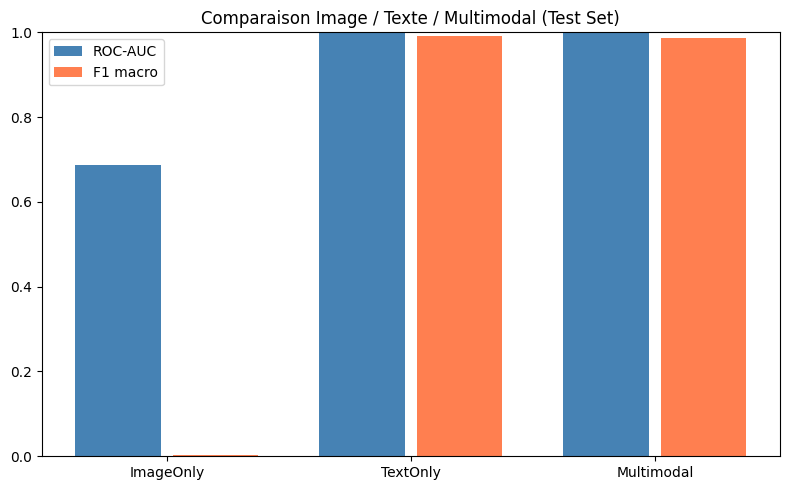

In [32]:
test_results = {}

for name, model_cls in [
    ('ImageOnly',  ImageOnlyModel),
    ('TextOnly',   TextOnlyModel),
    ('Multimodal', MultimodalModel),
]:
    model = model_cls().to(DEVICE)
    model.load_state_dict(torch.load(f'{WORK_DIR}/models/MM_{name}_best.pth', map_location=DEVICE))
    model.eval()

    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, txts, labels in val_loader:
            imgs, txts = imgs.to(DEVICE), txts.to(DEVICE)
            probs = torch.sigmoid(model(imgs, txts)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    y_pred = (y_prob >= 0.5).astype(int)

    try:    auc    = roc_auc_score(y_true, y_prob, average='macro')
    except: auc    = 0.0
    f1     = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:    pr_auc = average_precision_score(y_true, y_prob, average='macro')
    except: pr_auc = 0.0

    test_results[name] = {'roc_auc': auc, 'f1_macro': f1, 'pr_auc': pr_auc}
    print(f'{name:12s} | ROC-AUC: {auc:.4f} | F1: {f1:.4f} | PR-AUC: {pr_auc:.4f}')

# Graphique comparatif
fig, ax = plt.subplots(figsize=(8, 5))
models = list(test_results.keys())
aucs   = [test_results[m]['roc_auc'] for m in models]
f1s    = [test_results[m]['f1_macro'] for m in models]
x = np.arange(len(models))
ax.bar(x - 0.2, aucs, 0.35, label='ROC-AUC', color='steelblue')
ax.bar(x + 0.2, f1s,  0.35, label='F1 macro', color='coral')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1); ax.legend()
ax.set_title('Comparaison Image / Texte / Multimodal (Test Set)')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/figures/MM_comparaison.png', dpi=150)
plt.show()

In [33]:
model_mm = MultimodalModel().to(DEVICE)
model_mm.load_state_dict(torch.load(f'{WORK_DIR}/models/MM_Multimodal_best.pth', map_location=DEVICE))
model_mm.eval()

all_probs_full, all_probs_notxt, all_labels = [], [], []

with torch.no_grad():
    for imgs, txts, labels in test_loader:
        imgs, txts = imgs.to(DEVICE), txts.to(DEVICE)
        probs_full  = torch.sigmoid(model_mm(imgs, txts)).cpu().numpy()
        txts_zeros  = torch.zeros_like(txts)
        probs_notxt = torch.sigmoid(model_mm(imgs, txts_zeros)).cpu().numpy()
        all_probs_full.append(probs_full)
        all_probs_notxt.append(probs_notxt)
        all_labels.append(labels.numpy())

y_true       = np.concatenate(all_labels)
y_prob_full  = np.concatenate(all_probs_full)
y_prob_notxt = np.concatenate(all_probs_notxt)

try:    auc_full  = roc_auc_score(y_true, y_prob_full,  average='macro')
except: auc_full  = 0.0
try:    auc_notxt = roc_auc_score(y_true, y_prob_notxt, average='macro')
except: auc_notxt = 0.0

print('── Robustesse du modèle multimodal ──')
print(f'  Avec texte  → ROC-AUC : {auc_full:.4f}')
print(f'  Sans texte  → ROC-AUC : {auc_notxt:.4f}')
print(f'  Dégradation : {((auc_full - auc_notxt) / auc_full * 100):.1f}%')

── Robustesse du modèle multimodal ──
  Avec texte  → ROC-AUC : 0.9998
  Sans texte  → ROC-AUC : 0.5001
  Dégradation : 50.0%


In [34]:
from IPython.display import FileLink
import os

print('Modèles disponibles :')
for f in os.listdir(f'{WORK_DIR}/models'):
    size = os.path.getsize(f'{WORK_DIR}/models/{f}') / 1e6
    print(f'  {f} ({size:.1f} Mo)')
    display(FileLink(f'models/{f}'))

Modèles disponibles :
  MM_ImageOnly_best.pth (0.5 Mo)


/kaggle/working/models/MM_ImageOnly_best.pth

  MM_Multimodal_best.pth (2.1 Mo)


/kaggle/working/models/MM_Multimodal_best.pth

  MM_TextOnly_best.pth (0.9 Mo)


/kaggle/working/models/MM_TextOnly_best.pth